### 분석 결론

서울 지하철 246개 역 중 편의시설 중앙값은 TOTAL 11개, 무임비중 중앙값은 20%
대부분의 역이 왼쪽(시설 적음)에 밀집 → 서울 지하철 전반적으로 시설 부족

1순위 집중 관리 구역 (고비중-저시설)
    역      무임비중    시설 수       무임승하차
제기동       55%         5개         558,794명
청량리       42%         9개         561,250명
종로5가      34%         3개         487,010명
불암산       30%         7개         168,025명
길동         33%         6개         165,647명

"무임 이용 비중이 높고 절대 이용 인원도 많지만 편의시설이 부족한 역으로,
즉각적인 개선이 필요하다."

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
base_df = pd.read_csv('../../data/processed/team/subway_merged_base.csv')

In [3]:
base_df.head()

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94


In [4]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지하철역     244 non-null    object 
 1   호선명      244 non-null    object 
 2   총승차인원    244 non-null    int64  
 3   무임승차인원   244 non-null    int64  
 4   총하차인원    244 non-null    int64  
 5   무임하차인원   244 non-null    int64  
 6   전체승하차    244 non-null    int64  
 7   무임승하차    244 non-null    int64  
 8   무임승하차비중  244 non-null    float64
 9   EV       244 non-null    int64  
 10  ES       244 non-null    int64  
 11  TOTAL    244 non-null    int64  
 12  시설부하지수   244 non-null    float64
dtypes: float64(2), int64(9), object(2)
memory usage: 24.9+ KB


In [5]:
# 기준선
x_mid = base_df['TOTAL'].median()
y_mid = base_df['무임승하차비중'].median()

# 4섹터 라벨링 
def get_sector(row):
    hi_y = row['무임승하차비중'] >= y_mid
    hi_x = row['TOTAL'] >= x_mid
    if hi_y and not hi_x:
        return '고비중-저시설 (집중관리)'   # 왼쪽 위
    elif hi_y and hi_x:
        return '고비중-고시설 (현상유지)'   # 오른쪽 위
    elif not hi_y and not hi_x:
        return '저비중-저시설 (일반관리)'   # 왼쪽 아래
    else:
        return '저비중-고시설 (여유구역)'   # 오른쪽 아래

base_df['섹터'] = base_df.apply(get_sector, axis=1)

In [6]:
# 색상·순서 설정 
sector_order = [
    '고비중-저시설 (집중관리)',
    '고비중-고시설 (현상유지)',
    '저비중-저시설 (일반관리)',
    '저비중-고시설 (여유구역)',
]
colors = {
    '고비중-저시설 (집중관리)': '#e74c3c',
    '고비중-고시설 (현상유지)': '#e67e22',
    '저비중-저시설 (일반관리)': '#3498db',
    '저비중-고시설 (여유구역)': '#27ae60',
}

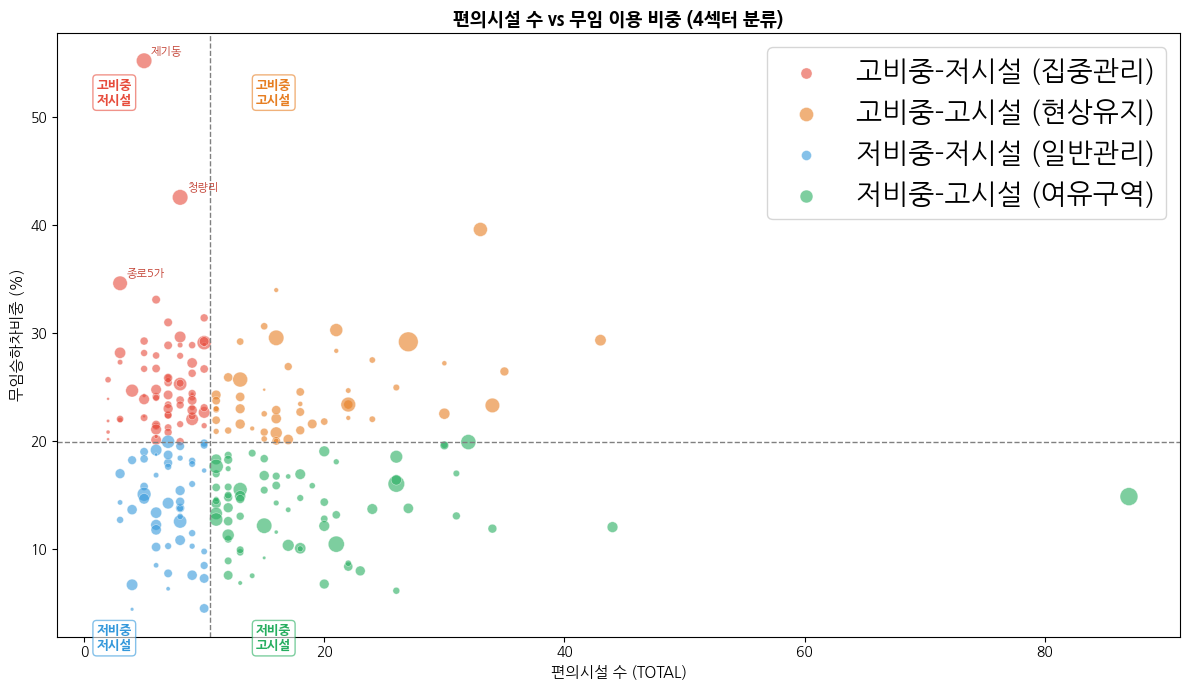

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

for sector in sector_order:
    sub = base_df[base_df['섹터'] == sector]
    ax.scatter(
        sub['TOTAL'],
        sub['무임승하차비중'],
        s=sub['무임승하차'] / base_df['무임승하차'].max() * 200,
        color=colors[sector],
        alpha=0.6,
        label=sector,
        edgecolors='white',
        linewidths=0.4,
    )

# 기준선 
ax.axvline(x=x_mid, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=y_mid, color='gray', linestyle='--', linewidth=1)

# 섹터 라벨
x_max = base_df['TOTAL'].max()
y_max = base_df['무임승하차비중'].max()

label_positions = [
    (x_mid * 0.1, y_max * 0.97, '고비중\n저시설', '#e74c3c'),
    (x_mid + (x_max - x_mid) * 0.05, y_max * 0.97, '고비중\n고시설', '#e67e22'),
    (x_mid * 0.1, y_mid * 0.15, '저비중\n저시설', '#3498db'),
    (x_mid + (x_max - x_mid) * 0.05, y_mid * 0.15, '저비중\n고시설', '#27ae60'),
]

for lx, ly, text, color in label_positions:
    ax.text(lx, ly, text, fontsize=9, color=color, fontweight='bold',
            va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6, ec=color))

#핵심 역 레이블 (집중관리 구역 상위 3개)
top3 = (
    base_df[base_df['섹터'] == '고비중-저시설 (집중관리)']
    .nlargest(3, '무임승하차')
)
for _, row in top3.iterrows():
    ax.annotate(
        row['지하철역'],
        xy=(row['TOTAL'], row['무임승하차비중']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, color='#c0392b',
    )

# 범례 - 축 설정 
ax.legend(loc='upper right', fontsize=20, framealpha=0.8)
ax.set_xlabel('편의시설 수 (TOTAL)', fontsize=11)
ax.set_ylabel('무임승하차비중 (%)', fontsize=11)
ax.set_title('편의시설 수 vs 무임 이용 비중 (4섹터 분류)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()